# Experiment Tracking with MLflow

This notebook demonstrates experiment tracking using MLflow. The best-performing model from Phase 2 (Random Forest) is logged along with its parameters, evaluation metrics, trained model, and visual artifacts to ensure reproducibility.

In [1]:
import datetime
run_id = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")

In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
import joblib
import mlflow
import mlflow.sklearn

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

In [3]:
df = pd.read_csv("data/processed/heart_clean.csv")

# Convert target to binary if required
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

X = df.drop("target", axis=1)
y = df["target"]

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### CONFUSION MATRIX UTITLITY FUNCTION

In [5]:
def build_confusion_matrix(y_test, y_pred):
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )
    
    plt.title("Confusion Matrix")
    
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    path = f"confusion_matrix_{run_id}.png"
    
    plt.savefig(path)
    return path

### Preprocessing Pipeline

In [6]:
numerical_features = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features)
    ],
    remainder="passthrough"
)

### ML MODEL BUILD PIPELINE

In [7]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=200,
            random_state=42
        ))
    ]
)

### START MLFLOW EXPERIMENT TRACKING

In [8]:
mlflow.set_experiment("Heart Disease Prediction")

<Experiment: artifact_location='file:///C:/Users/aditi/OneDrive/Documents/MTECH/MLOps/Assignment1/mlruns/1', creation_time=1783785018058, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783785018058, lifecycle_stage='active', name='Heart Disease Prediction', tags={}, trace_location=None, workspace='default'>

In [9]:
# mlflow.set_tracking_uri("file:///C:/Users/aditi/OneDrive/Documents/MTECH/MLOps/Assignment1/mlruns")

### TRAINING MODEL AND LOGGING WITH MLFLOW

Experiment logged successfully!


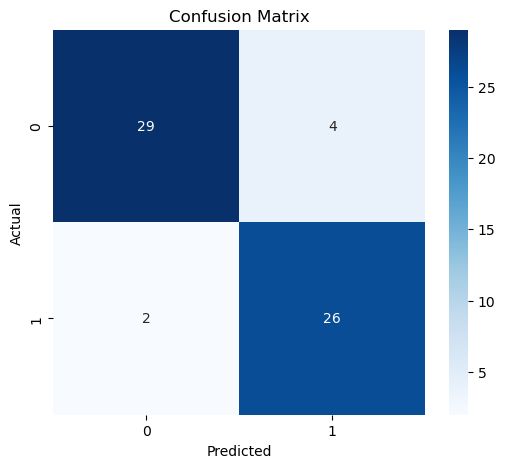

In [11]:
with mlflow.start_run():

    # Train
    rf_pipeline.fit(X_train, y_train)

    # Predictions
    y_pred = rf_pipeline.predict(X_test)
    y_prob = rf_pipeline.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    # Log Parameters
    mlflow.log_param("model", "Random Forest")
    mlflow.log_param("n_estimators", 200)
    mlflow.log_param("random_state", 42)

    # Log Metrics
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # Log Model
    mlflow.sklearn.log_model(
        rf_pipeline,
        name="model",
        skops_trusted_types = ['numpy.dtype', 'sklearn.compose._column_transformer._RemainderColsList']
    )

    # Build Confusion Matrix
    cmpath = build_confusion_matrix(y_test, y_pred)

    # Log Confusion Matrix Artefact to MLFLOW
    mlflow.log_artifact(cmpath)
    
    print("Experiment logged successfully!")

### SAVE PIPELINE

In [12]:
os.makedirs("models", exist_ok=True)

joblib.dump(
    rf_pipeline,
    "models/heart_disease_rf_pipeline.pkl"
)

print("Pipeline saved successfully!")

Pipeline saved successfully!


### Conclusion

MLflow was successfully integrated into the machine learning workflow.

The Random Forest model, along with its parameters, evaluation metrics, trained pipeline, and artifacts, was logged automatically.

This experiment tracking process ensures reproducibility, simplifies model comparison, and supports deployment in later stages of the MLOps pipeline.